# METAR Temperature Visualization with Lonboard
---

## Overview
   
Within this notebook, we will create an interactive visualization of the latest METAR data across all stations. We will use the following libraries for our visualizations:

1. [Geopandas](https://geopandas.org/en/stable/)
2. [Lonboard](https://developmentseed.org/lonboard/latest/)

## Prerequisites
| Concepts | Importance | Notes |
| --- | --- | --- |
| [Pandas](https://foundations.projectpythia.org/core/pandas.html) | Required | Tabular Datasets |

- **Time to learn**: 10 minutes
---

In [40]:
from IPython.display import Image
import duckdb
import numpy as np
import pandas as pd
import geopandas as gpd
from datetime import datetime, timedelta, timezone
from lonboard import viz, Map, ScatterplotLayer, HeatmapLayer
import hvplot
import hvplot.pandas
import holoviews as hv
from palettable.colorbrewer.diverging import BrBG_10, RdBu_10
from pathlib import Path
import geopandas as gpd
import shapely
from lonboard.colormap import apply_continuous_cmap
# from lonboard.controls import MultiRangeSlider
# from lonboard.layer_extension import DataFilterExtension

In [2]:
url = 'https://data.source.coop/dynamical/asos-parquet/year=2026/data.parquet'

## Get the past three days of data
This query will request just the latest hours worth of data across all stations.

In [3]:
time_1 = datetime.now()
print(f"end time: {time_1}")

end time: 2026-06-18 19:54:34.544909


In [4]:
time_0 = datetime.now() - timedelta(hours=72)
print(f"start time: {time_0}")

start time: 2026-06-15 19:54:34.549363


# Query the database for all data between those timestamps

In [5]:
df = duckdb.execute("""
    SELECT *
    FROM read_parquet($1, hive_partitioning=true)
    WHERE 
---      country = 'US' AND
    valid BETWEEN $2 AND $3
    ORDER BY country
""", [url, time_0, time_1]).fetchdf()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Print the first couple columns of data to get an understanding of the structure

In [6]:
df.head(4)

,station,valid,longitude,latitude,tmpf,tmpc,dwpf,dwpc,relh,drct,...,state,geometry,name,elevation,country,county,wfo,tzname,bbox,year
0,NZQN,2026-06-17 08:00:00+00:00,168.7392,-45.0211,35.6,2.0,32.0,0.0,86.58,30.0,...,AU,"[1, 1, 0, 0, 0, 129, 38, 194, 134, 167, 23, 10...",Queenstown,356.0,AU,NaN,NaN,Pacific/Auckland,"{'xmin': 168.7392, 'ymin': -45.0211, 'xmax': 1...",2026
1,ANYN,2026-06-16 08:00:00+00:00,166.9191,-0.5475,80.6,27.0,75.2,24.0,83.70,240.0,...,AU,"[1, 1, 0, 0, 0, 29, 56, 103, 68, 105, 221, 100...",Nauru,7.0,AU,NaN,NaN,Pacific/Nauru,"{'xmin': 166.9191, 'ymin': -0.5475, 'xmax': 16...",2026
2,NZQN,2026-06-15 21:00:00+00:00,168.7392,-45.0211,39.2,4.0,35.6,2.0,86.79,50.0,...,AU,"[1, 1, 0, 0, 0, 129, 38, 194, 134, 167, 23, 10...",Queenstown,356.0,AU,NaN,NaN,Pacific/Auckland,"{'xmin': 168.7392, 'ymin': -45.0211, 'xmax': 1...",2026
3,NZQN,2026-06-16 15:30:00+00:00,168.7392,-45.0211,44.6,7.0,42.8,6.0,93.35,220.0,...,AU,"[1, 1, 0, 0, 0, 129, 38, 194, 134, 167, 23, 10...",Queenstown,356.0,AU,NaN,NaN,Pacific/Auckland,"{'xmin': 168.7392, 'ymin': -45.0211, 'xmax': 1...",2026


## Understanding the data columns

The documentation can be found here for the individual columns:

https://github.com/dynamical-org/asos-parquet#key-fields

Print the columns as follows:

In [7]:
df.columns

Index(['station', 'valid', 'longitude', 'latitude', 'tmpf', 'tmpc', 'dwpf',
       'dwpc', 'relh', 'drct', 'sknt', 'gust', 'alti', 'mslp', 'vsby', 'p01i',
       'p01m', 'state', 'geometry', 'name', 'elevation', 'country', 'county',
       'wfo', 'tzname', 'bbox', 'year'],
      dtype='str')

Now create bind descriptions to each of the columns

In [8]:
variables = {
    'tmpf': "Temperature in Fahrenheit",
    'tmpc': "Temperature in Celsius",
    'dwpf': "Dewpoint in Fahrenheit",
    'dwpc': "Dewpoint in Celsius", 
    'relh': "Relative humidity in percent", 
    'drct': "Wind direction in degrees", 
    'sknt': "Wind speed in knots", 
    'gust': "Wind gusts in knots", 
    'alti': "Altimeter setting in inches of mercury", 
    'mslp': "Mean sea level pressure", 
    'vsby': "Visibility in statute miles", 
    'p01i': "P01I", 
    'p01m': "P01M"
}

## Plot Timeseries data from a station local to Boulder, Colorado
Select all the data from the Boulder station, "BDU" and plot it.

In [9]:
df_bdu = df.loc[df['station'] == "BDU"]
df_bdu.head(2)

,station,valid,longitude,latitude,tmpf,tmpc,dwpf,dwpc,relh,drct,...,state,geometry,name,elevation,country,county,wfo,tzname,bbox,year
276959,BDU,2026-06-15 19:55:00+00:00,-105.2258,40.0394,77.0,25.0,39.2,4.0,25.7,70.0,...,CO,"[1, 1, 0, 0, 0, 245, 219, 215, 129, 115, 78, 9...",Boulder,1612.0,US,Boulder,BOU,America/Denver,"{'xmin': -105.2258, 'ymin': 40.0394, 'xmax': -...",2026
276960,BDU,2026-06-15 20:15:00+00:00,-105.2258,40.0394,77.0,25.0,39.2,4.0,25.7,90.0,...,CO,"[1, 1, 0, 0, 0, 245, 219, 215, 129, 115, 78, 9...",Boulder,1612.0,US,Boulder,BOU,America/Denver,"{'xmin': -105.2258, 'ymin': 40.0394, 'xmax': -...",2026


In [10]:
df_select = pd.DataFrame({
    'date': df_bdu['valid'],
    'tmpc': df_bdu['tmpc'],
    'dwpc': df_bdu['dwpc'],
    'relh': df_bdu['relh'],
    'drct': df_bdu['drct'],
    'sknt': df_bdu['sknt'],
    'alti': df_bdu['alti'],
}).set_index('date')

# print the head of the dataframe
df_select.head(2)

,tmpc,dwpc,relh,drct,sknt,alti
date,,,,,,
2026-06-15 19:55:00+00:00,25.0,4.0,25.7,70.0,3.0,30.14
2026-06-15 20:15:00+00:00,25.0,4.0,25.7,90.0,3.0,30.13


Iterate through some variables and compose an interactive plot of the past three days

In [11]:
hv.Layout(
    [df_select[i].hvplot.line(title=f"{variables[i]}", width=300) for i in [
        'tmpc',
        'dwpc',
        'relh',
        'drct',
        'sknt',
        'alti'
    ]]
).cols(2)

:Layout
   .Curve.Tmpc :Curve   [date]   (tmpc)
   .Curve.Dwpc :Curve   [date]   (dwpc)
   .Curve.Relh :Curve   [date]   (relh)
   .Curve.Drct :Curve   [date]   (drct)
   .Curve.Sknt :Curve   [date]   (sknt)
   .Curve.Alti :Curve   [date]   (alti)

## Plotting Across All Stations using Lonboard

Now we will use the library (Lonboard)[https://developmentseed.org/lonboard/latest/] to plot the latest temperature data across all stations.

Get the newest observations from each station

In [12]:
df_latest = df.groupby('station').tail(1).sort_values(by='station', ignore_index=True)
df_latest.head(3)

,station,valid,longitude,latitude,tmpf,tmpc,dwpf,dwpc,relh,drct,...,state,geometry,name,elevation,country,county,wfo,tzname,bbox,year
0,00U,2026-06-18 19:15:00+00:00,-107.6604,45.7444,71.6,22.00,42.8,6.00,35.40,160.0,...,MT,"[1, 1, 0, 0, 0, 209, 145, 92, 254, 67, 234, 90...",Big Horn County,914.23517,US,Big Horn,BYZ,America/Denver,"{'xmin': -107.6604, 'ymin': 45.7444, 'xmax': -...",2026
1,01M,2026-06-18 19:15:00+00:00,-88.2011,34.4917,78.0,25.56,70.5,21.39,77.81,170.0,...,MS,"[1, 1, 0, 0, 0, 112, 206, 136, 210, 222, 12, 8...",Belmont,173.01176,US,Tishomingo,MEG,America/Chicago,"{'xmin': -88.2011, 'ymin': 34.4917, 'xmax': -8...",2026
2,04V,2026-06-18 19:15:00+00:00,-106.1700,38.1000,86.0,30.00,19.4,-7.00,8.54,290.0,...,CO,"[1, 1, 0, 0, 0, 123, 20, 174, 71, 225, 138, 90...",SAGUACHE MUNI,2385.00000,US,Saguache,PUB,America/Denver,"{'xmin': -106.17, 'ymin': 38.1, 'xmax': -106.1...",2026


In [13]:
df_latest.columns

Index(['station', 'valid', 'longitude', 'latitude', 'tmpf', 'tmpc', 'dwpf',
       'dwpc', 'relh', 'drct', 'sknt', 'gust', 'alti', 'mslp', 'vsby', 'p01i',
       'p01m', 'state', 'geometry', 'name', 'elevation', 'country', 'county',
       'wfo', 'tzname', 'bbox', 'year'],
      dtype='str')

Create a geometry from the point data using longitude and latitude

In [14]:
geometry = gpd.points_from_xy(df_latest['longitude'], df_latest['latitude'])

And create a GeoPandas DataFrame. We want the data in a form with columns of: [index, feature0, ..., featureN, geometry]. We will use 'tmpf' which is the temperature in degrees fahrenheit as the singular feature.

In [15]:
gdf2 = gpd.GeoDataFrame(
    df_latest[['tmpf', 'relh']],
    geometry=geometry,
    crs="EPSG:4326",
)
gdf2.head(3)

,tmpf,relh,geometry
0,71.6,35.40,POINT (-107.6604 45.7444)
1,78.0,77.81,POINT (-88.2011 34.4917)
2,86.0,8.54,POINT (-106.17 38.1)


Figure out the minimum and maximum temperature values for the dataset

In [16]:
min_bound = np.min(gdf2['tmpf'])
max_bound = np.max(gdf2['tmpf'])

print(f"min temperature: {np.min(gdf2['tmpf'])} degF, max temperature: {np.max(gdf2['tmpf'])} degF")

min temperature: 28.4 degF, max temperature: 108.0 degF


In [18]:
normalized_value = 1 - (gdf2["tmpf"] - min_bound) / (max_bound - min_bound)
fill_color = apply_continuous_cmap(normalized_value, RdBu_10)
radius = 20_000

In [35]:
layer = ScatterplotLayer.from_geopandas(
    gdf2,
    get_fill_color=fill_color,
    get_radius=radius,
    radius_units="meters",
    radius_min_pixels=0.1,
)

## Mapping the Temperature Gradient with Lonboard
Colors are plotted with a red-blue divergent color scheme. Warmer temperatures are denoted with 'red' and cooler temperatures are 'blue'.

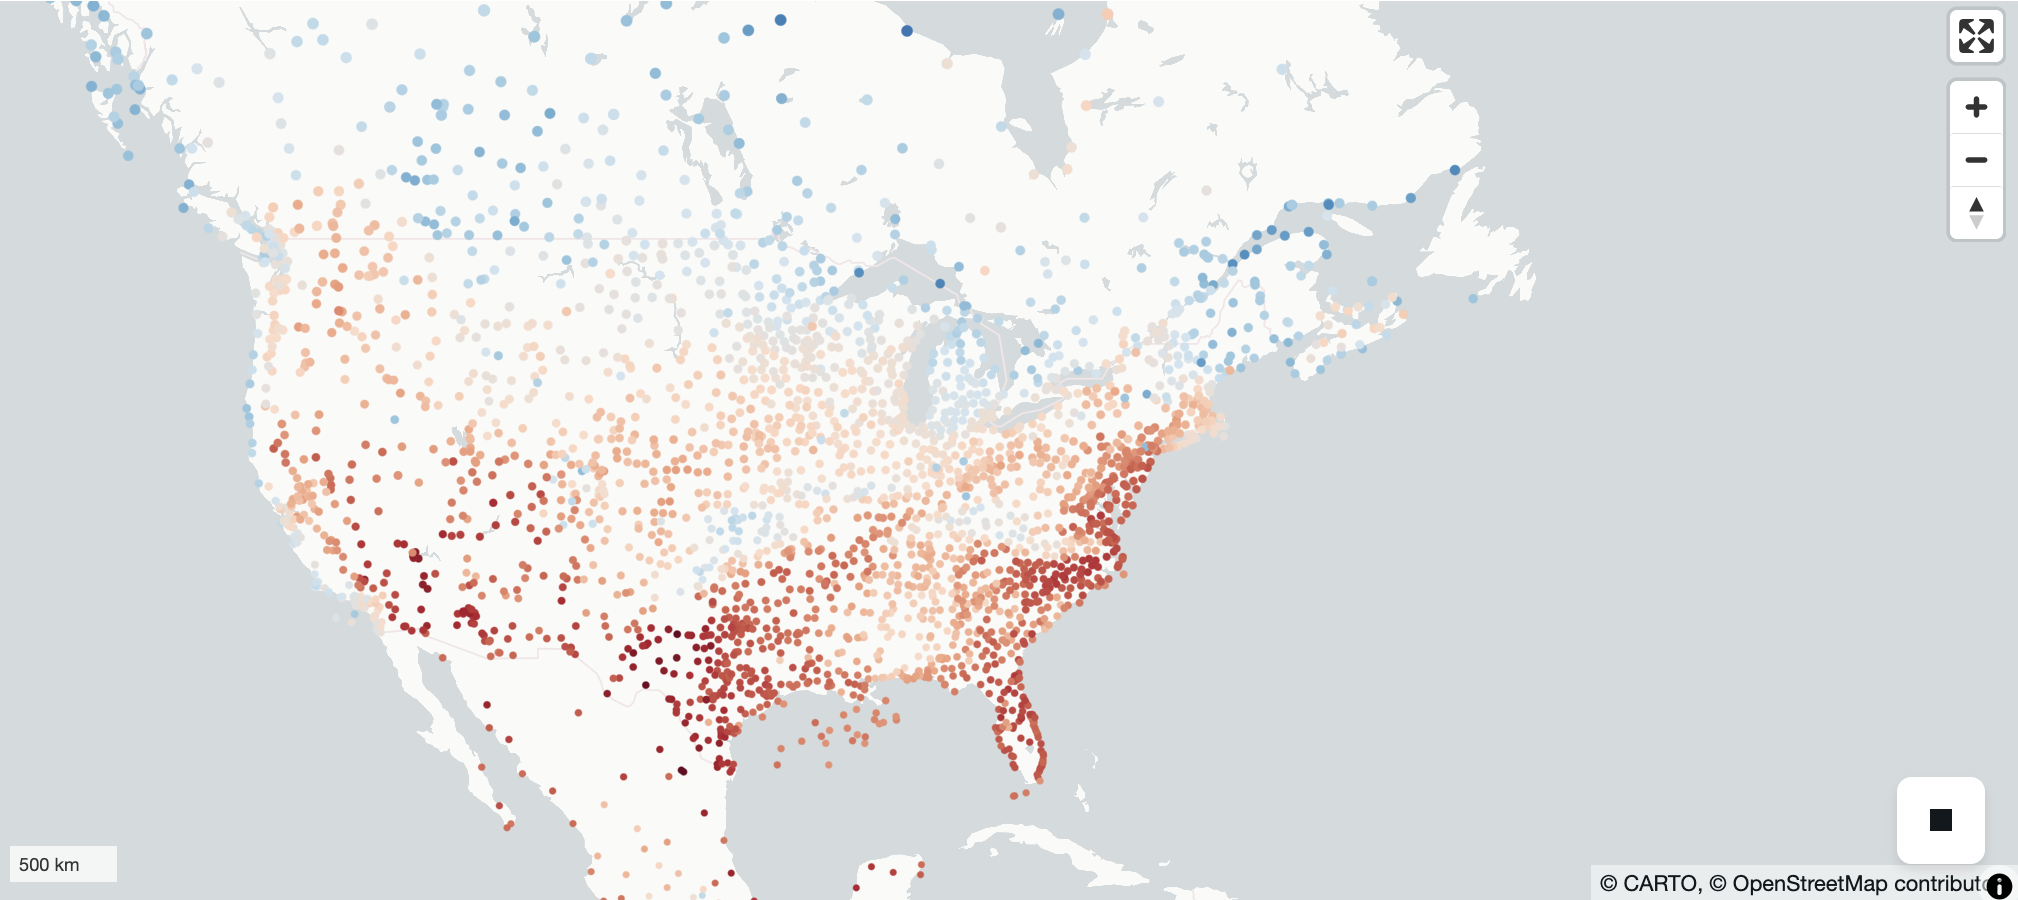

In [39]:
Image(filename='thumbnails/temperature.png')

In [36]:
m

## And Map the Relative Humidity ('relh')
Dark green means a higher value. Red means a lower value.

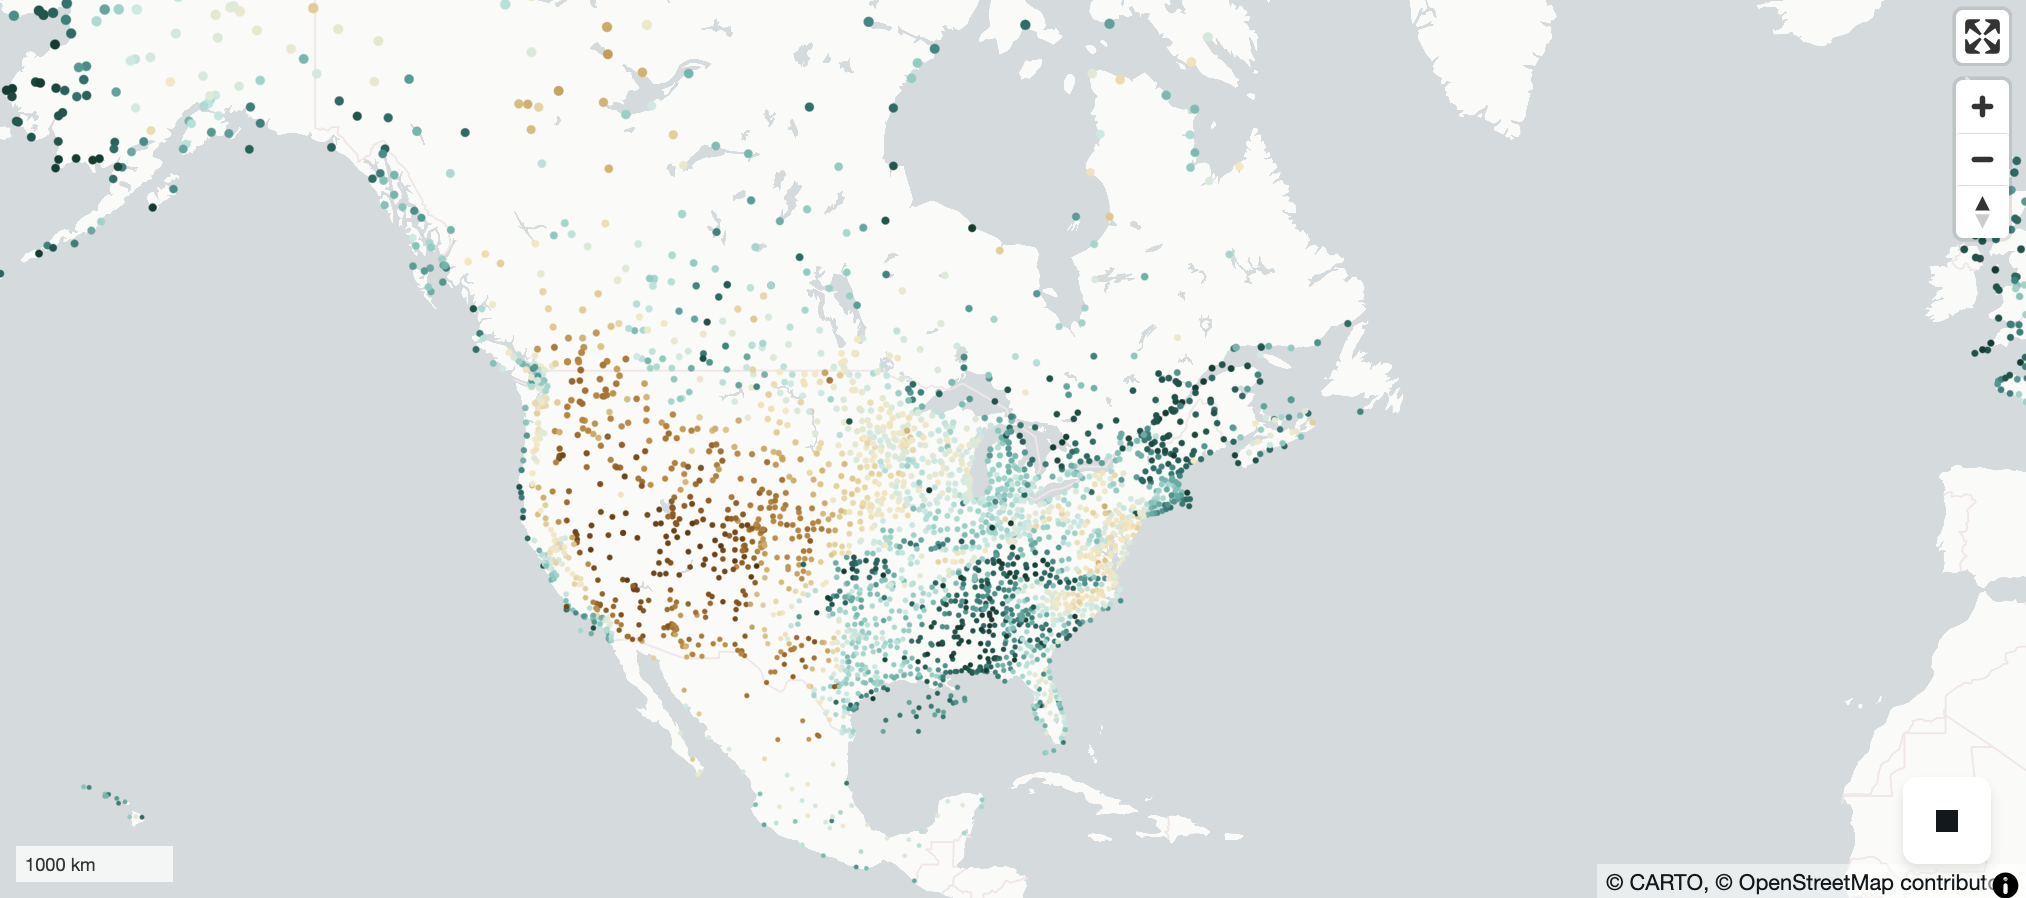

In [41]:
Image(filename='thumbnails/relative_humidity.png')

In [42]:
min_bound = np.min(gdf2['relh'])
max_bound = np.max(gdf2['relh'])
normalized_value = (gdf2["relh"] - min_bound) / (max_bound - min_bound)
fill_color2 = apply_continuous_cmap(normalized_value, BrBG_10)
radius2 = 20_000
layer2 = ScatterplotLayer.from_geopandas(
    gdf2,
    # extensions=[filter_extension],
    get_fill_color=fill_color2,
    get_radius=radius2,
    radius_units="meters",
    radius_min_pixels=0.1,
)
m = Map(layer2)
m

## References

1. [GeoPandas](https://geopandas.org)
1. [EPSG](https://epsg.io)

## What's next?
Expanding on the plotting capability by adding a legend. And more interactively visualize other components like wind 'u' and 'v' components.